
## Нелинейный упругий стержень — формулы
Параметры: длина L, EI— жёсткость на изгиб, нагрузка P (конец вниз).

Эластика (планарный стержень, без растяжения):
$$
\theta''(s) + \frac{P}{EI}\sin\theta(s) = 0,\\
x'(s)=\cos\theta(s),\quad y'(s)=\sin\theta(s),\\
$$
$$
\text{с }s\in[0,L],\;\theta(0)=0\;\text{(зажатие, горизонтально)},\;\theta'(0)=k_0\;\text{(неизвестно)}.
$$
Крайнее условие (свободный конец): $\theta'(L)=0\;\text{(момент на конце = 0)}$

Задача стрельбы: подобрать $k_0\text{ так, чтобы }F(k_0)=\theta'(L;k_0)=0$


В линейной аппроксимации (малые углы): $\theta'' + \frac{P}{EI}\theta=0\Rightarrow \delta_{lin}=\frac{P L^3}{3EI}
\text{— теоретическая формула для концевого прогиба при сосредоточенной нагрузке P (кантилевер).}$


In [1]:
import numpy as np
from time import perf_counter
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

# %%
# Параметры стержня (примерные)
L = 1.0            # длина, м
E = 2.1e11         # модуль Юнга, Па (сталь)
I = 1e-6           # момент инерции поперечного сечения, м^4
EI = E*I

# %%
# ODE системы: z = [theta, k (=theta'), x, y]
def elastica_rhs(s, z, P, EI=EI):
    theta, k, x, y = z
    dtheta_ds = k
    dk_ds = -(P/EI)*np.sin(theta)
    dx_ds = np.cos(theta)
    dy_ds = np.sin(theta)
    return [dtheta_ds, dk_ds, dx_ds, dy_ds]

# Функция-стрелок: для заданного начального k0 интегрируем до s=L и возвращаем theta'(L)
def shoot_k0(k0, P, L=L):
    z0 = [0.0, k0, 0.0, 0.0]
    sol = solve_ivp(elastica_rhs, [0.0, L], z0, args=(P,), rtol=1e-8, atol=1e-8, max_step=L/200.0)
    thetaL = sol.y[0, -1]
    kL = sol.y[1, -1]
    xL = sol.y[2, -1]
    yL = sol.y[3, -1]
    return kL, thetaL, xL, yL, sol

# %%
# Поиск k0 методом brent (root_scalar) с предварительным сканом для брукета
def find_k0_brent(P, k0_bounds=(-50.0,50.0), nscan=101):
    ks = np.linspace(k0_bounds[0], k0_bounds[1], nscan)
    vals = np.empty_like(ks)
    for i,k in enumerate(ks):
        try:
            vals[i] = shoot_k0(k, P)[0]
        except Exception:
            vals[i] = np.nan
    # найти пару с изменением знака
    idx = np.where(np.isfinite(vals[:-1]) & np.isfinite(vals[1:]) & (np.sign(vals[:-1])!=np.sign(vals[1:])))[0]
    if len(idx)==0:
        return None, ks, vals
    i = idx[0]
    k_lo, k_hi = ks[i], ks[i+1]
    sol = root_scalar(lambda kk: shoot_k0(kk,P)[0], bracket=(k_lo, k_hi), method='brentq', xtol=1e-8)
    k0 = sol.root
    kL, thetaL, xL, yL, sol_ivp = shoot_k0(k0, P)
    return dict(k0=k0, kL=kL, thetaL=thetaL, xL=xL, yL=yL, sol=sol_ivp), ks, vals

# %%
# Простейший вариант метода Ньютона (одномерный) для уточнения k0 — численное приближение производной
def find_k0_newton(P, k0_init, tol=1e-8, maxiter=50, h=1e-6):
    k = float(k0_init)
    for it in range(maxiter):
        f_k = shoot_k0(k,P)[0]
        # численная производная
        f_k_ph = shoot_k0(k+h, P)[0]
        df = (f_k_ph - f_k)/h
        if abs(df) < 1e-14:
            break
        k_new = k - f_k/df
        if abs(k_new - k) < tol:
            k = k_new
            break
        k = k_new
    kL, thetaL, xL, yL, sol_ivp = shoot_k0(k, P)
    return dict(k0=k, kL=kL, thetaL=thetaL, xL=xL, yL=yL, sol=sol_ivp)

In [2]:
# Поиск k0 методом brent (root_scalar) с предварительным сканом для брукета
def find_k0_brent(P, k0_bounds=(-50.0,50.0), nscan=101):
    ks = np.linspace(k0_bounds[0], k0_bounds[1], nscan)
    vals = np.empty_like(ks)
    for i,k in enumerate(ks):
        try:
            vals[i] = shoot_k0(k, P)[0]
        except Exception:
            vals[i] = np.nan
    # найти пару с изменением знака
    idx = np.where(np.isfinite(vals[:-1]) & np.isfinite(vals[1:]) & (np.sign(vals[:-1])!=np.sign(vals[1:])))[0]
    if len(idx)==0:
        return None, ks, vals
    i = idx[0]
    k_lo, k_hi = ks[i], ks[i+1]
    sol = root_scalar(lambda kk: shoot_k0(kk,P)[0], bracket=(k_lo, k_hi), method='brentq', xtol=1e-8)
    k0 = sol.root
    kL, thetaL, xL, yL, sol_ivp = shoot_k0(k0, P)
    return dict(k0=k0, kL=kL, thetaL=thetaL, xL=xL, yL=yL, sol=sol_ivp), ks, vals

In [3]:
# Тест для одного P: сравнение методов поиска k0
P_test = 100.0  # нагрузка, Н
res_brent, ks_scan, vals_scan = find_k0_brent(P_test, k0_bounds=(-10,10), nscan=201)
if res_brent is None:
    print('Brent не нашёл брукет. Показ результата скана:')
    i_best = np.nanargmin(np.abs(vals_scan))
    print('Лучшее приближение k0=', ks_scan[i_best], 'f=', vals_scan[i_best])
else:
    print('Brent нашёл k0=', res_brent['k0'], 'y_tip=', res_brent['yL'])
    # уточним Newton'ом, стартуя от nearby
    res_newt = find_k0_newton(P_test, res_brent['k0'])
    print('Newton уточнил k0=', res_newt['k0'], 'y_tip=', res_newt['yL'])


Brent нашёл k0= 0.0 y_tip= 0.0
Newton уточнил k0= 0.0 y_tip= 0.0


In [4]:
# Построение диаграммы "нагрузка — прогиб кончика" (сравнение линейной формулы)
P_vals = np.linspace(0.0, 1000.0, 25)  # диапазон нагрузок
y_nl = np.empty_like(P_vals)
k0_nl = np.empty_like(P_vals)
methods_time = {'brent':0.0, 'newton':0.0}
for i,P in enumerate(P_vals):
    t0 = perf_counter()
    res, ks, vals = find_k0_brent(P, k0_bounds=(-50,50), nscan=201)
    methods_time['brent'] += perf_counter()-t0
    if res is None:
        # попробуем минимизацию по |f| и затем Newton
        i_best = int(np.nanargmin(np.abs(vals)))
        k_guess = ks[i_best]
        t0 = perf_counter()
        res_n = find_k0_newton(P, k_guess)
        methods_time['newton'] += perf_counter()-t0
        y_nl[i] = res_n['yL']
        k0_nl[i] = res_n['k0']
    else:
        y_nl[i] = res['yL']
        k0_nl[i] = res['k0']

# Линейная теория: прогиб кончика для сосредоточенной силы P
y_lin = -P_vals * L**3 / (3*EI)

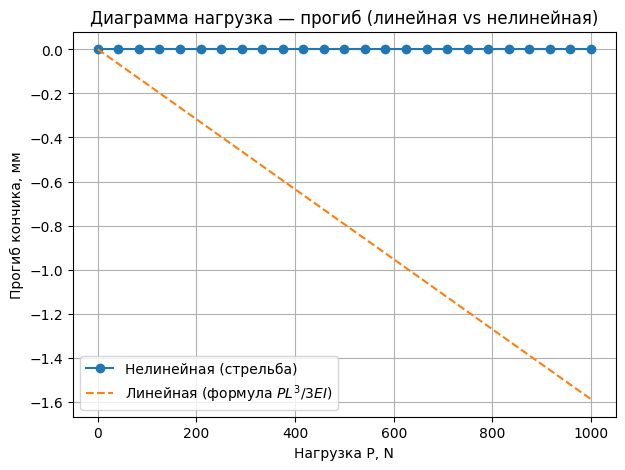

In [5]:
plt.figure(figsize=(7,5))
plt.plot(P_vals, y_nl*1e3, '-o', label='Нелинейная (стрельба)')
plt.plot(P_vals, y_lin*1e3, '--', label='Линейная (формула $PL^3/3EI$)')
plt.xlabel('Нагрузка P, N')
plt.ylabel('Прогиб кончика, мм')
plt.title('Диаграмма нагрузка — прогиб (линейная vs нелинейная)')
plt.legend(); plt.grid(True)

In [6]:
# Краткое сравнение скорости работы (оценка)
print('Время суммарно (brent attempts): %.2f s' % methods_time['brent'])
print('Замечание: при неудачных сканах метод Newton использует численную производную — медленнее, но часто бывает точнее при хорошей стартовой догадке.')

Время суммарно (brent attempts): 24.07 s
Замечание: при неудачных сканах метод Newton использует численную производную — медленнее, но часто бывает точнее при хорошей стартовой догадке.


### Заключение:
- Мы сформулировали задачу стрелками: подбор начальной кривизны $k_0$ так, чтобы на конце выполнялось условие свободного момента $\theta'(L)=0$.
- В линейной области результат совпадает с формулой $PL^3/(3EI)$; при больших нагрузках наблюдается расхождение (геометрическая нелинейность).
- Для численного решения метода Ньютона мы использовали одномерную версию с численной аппроксимацией производной; для многопараметрических задач имеет смысл формировать вариационные уравнения и решать систему для чувствительностей.

